i start by loading the dataset and creating useful time-based features like Month.

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/ethiopia.csv")

df["Country"] = "Ethiopia"

df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month


Before analysis, i clean and inspect the dataset:

- All occurrences of -999 are replaced with NaN, as they represent missing or invalid NASA data.
- Duplicate rows are checked and removed to ensure data integrity.
- Descriptive statistics  are generated to understand data distribution.
- Missing values are calculated for each column, along with their percentage.
-Columns with more than 5% missing values are highlighted because they may affect reliability and require careful handling during analysis.

In [7]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()
missing = df.isna().sum() 
percent = (missing / len(df)) * 100


i identify and handle extreme values in the dataset:

- Z-scores are computed for key weather variables to detect outliers.
- Values with |Z| > 3 are considered potential outliers.
- The number of outliers is reported for transparency.


Missing values are then handled using forward-fill or row removal depending on completeness. This ensures the dataset remains consistent for time-series analysis.

In [8]:
from scipy.stats import zscore 
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"] 
z_scores = np.abs(zscore(df[cols], nan_policy='omit')) 
outliers = (z_scores > 3).sum()
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


After cleaning, the dataset is saved into a new file for further analysis.

- The exported dataset will be used for all visualization and modeling steps.

In [9]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

here i explored how weather variables change over time.

- Monthly average temperature (T2M) is plotted to observe seasonal patterns.
- Warmest and coolest months are identified.
- Monthly total precipitation is plotted to analyze rainfall trends.

These visualizations help reveal climate patterns such as seasonal temperature shifts and rainy seasons

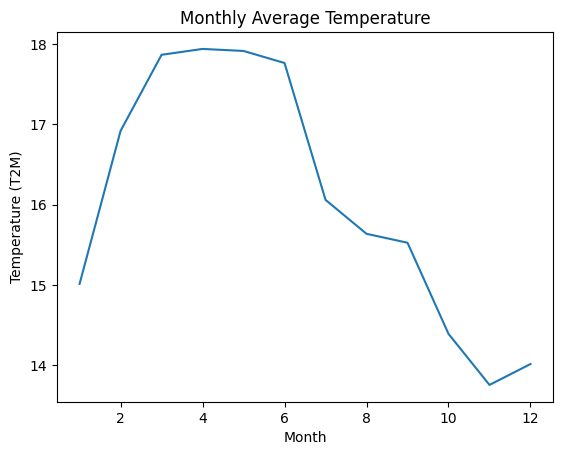

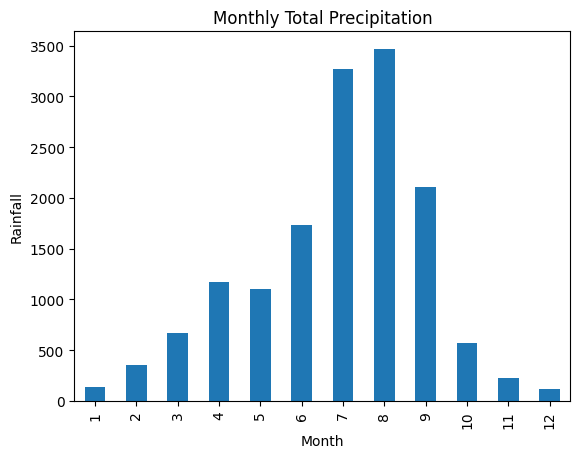

In [10]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.show()
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()


i examined relationships between weather variables:

- A correlation heatmap is used to identify strong positive or negative relationships.
- Scatter plots are used to explore:
  - Temperature vs humidity
  - Temperature range vs wind speed

The three strongest correlations are identified and interpreted to understand how climate variables interact with each other.

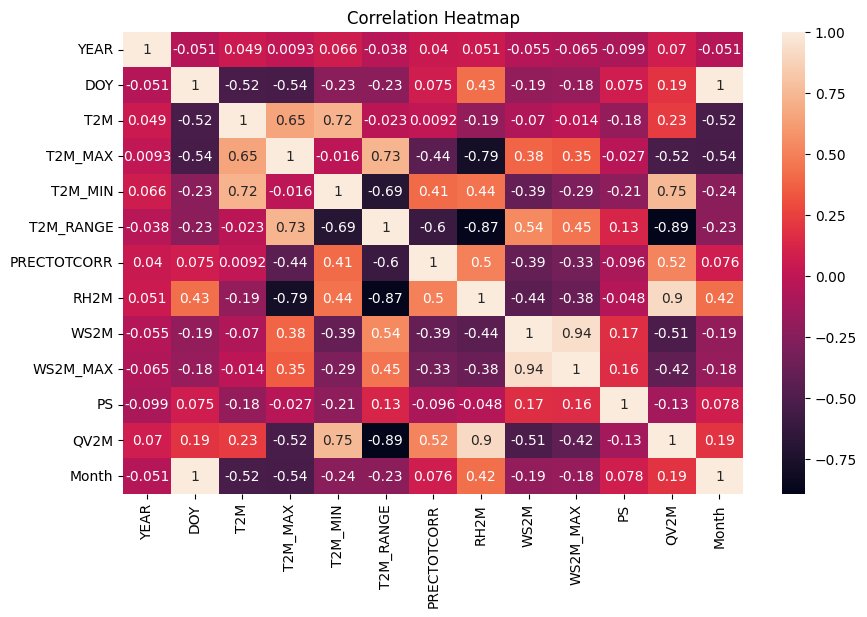

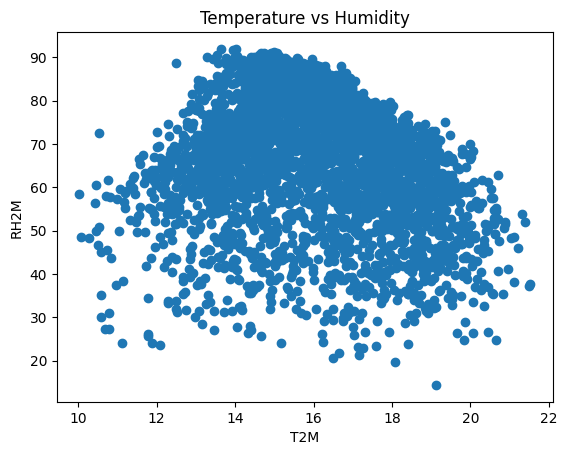

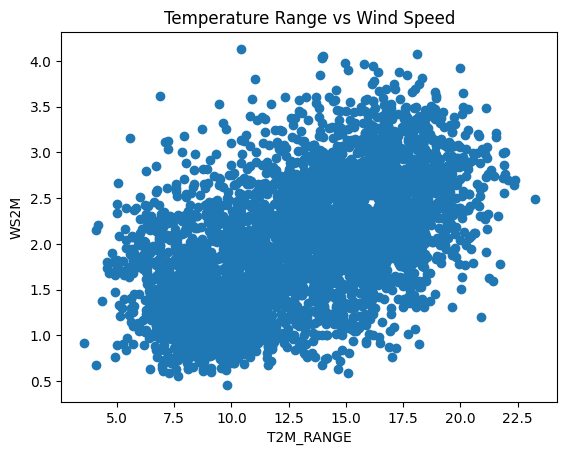

In [11]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

here i focused on understanding how values are distributed:

- A histogram of precipitation (PRECTOTCORR) is used to study rainfall distribution.
- A log scale is applied if the data is highly skewed.
- A  chart is used to visualize relationships between temperature, humidity, and rainfall intensity.

These visualizations help detect skewness, concentration, and variability in weather patterns.

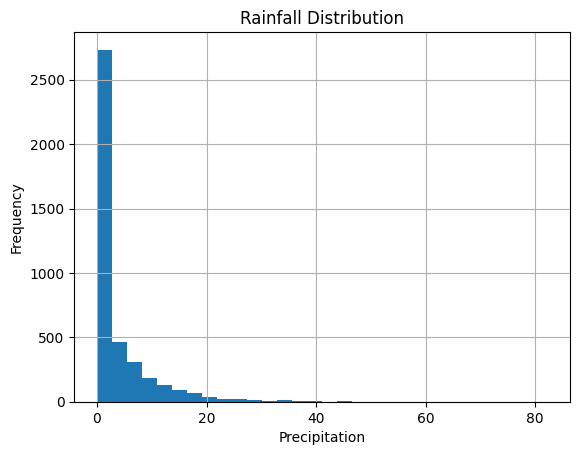

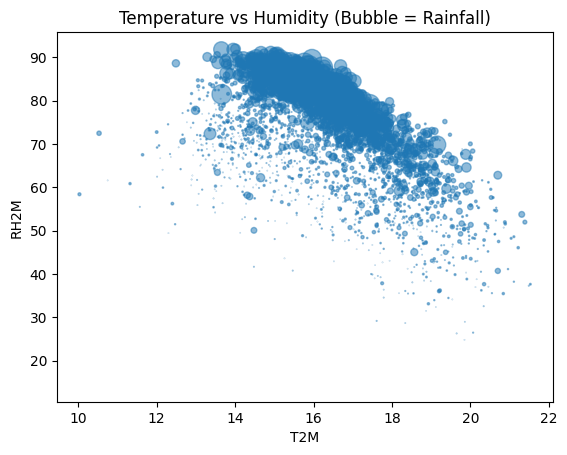

In [12]:
df["PRECTOTCORR"].hist(bins=30)
plt.title("Rainfall Distribution")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.show()
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 5,  
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.show()